# Bronze Parquet Sanity Check

This notebook quickly validates your Bronze outputs (historical & daily OOT):

1. Confirm the dataset exists and is readable
2. Print schema and row counts
3. Show a sample of rows
4. Basic quality checks (nulls %, min/max date if a date column is present)
5. Optional histograms for dates / delays

**Tip:** Run each section independently if you only have one of the paths ready.

In [41]:
# --- Configure your paths here ---
HIST_PATH = "../../datamart/bronze/flight/bronze_flight_historical.parquet"
OOT_PATH  = "../../datamart/bronze/flight/bronze_flight_oot.parquet"

# How many rows to sample into memory for quick checks
SAMPLE_N = None

In [42]:
import os
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

In [43]:
def dataset_exists(path: str) -> bool:
    return os.path.exists(path)

def open_dataset(path: str):
    return ds.dataset(path, format="parquet")

def head_dataset(dataset: ds.Dataset, n: int = 20) -> pd.DataFrame:
    """
    Return first n rows without reading the full dataset.
    """
    scanner = dataset.scanner(batch_size=n)  # no 'limit' arg in many pyarrow versions
    rows = []
    got = 0
    for batch in scanner.to_batches():
        take = min(n - got, batch.num_rows)
        if take > 0:
            rows.append(batch.slice(0, take))
            got += take
        if got >= n:
            break
    table = pa.Table.from_batches(rows) if rows else pa.table({})
    return table.to_pandas(types_mapper=pd.ArrowDtype)

def sample_dataset(dataset: ds.Dataset, n: int | None = SAMPLE_N):
    scan = dataset.scanner(batch_size=200_000)
    batches = []
    got = 0
    for batch in scan.to_batches():
        if n is None:
            batches.append(batch)            # take all batches
        else:
            take = min(n - got, batch.num_rows)
            if take > 0:
                batches.append(batch.slice(0, take))
                got += take
            if got >= n:
                break
    tbl = pa.Table.from_batches(batches) if batches else pa.table({})
    return tbl.to_pandas()

def try_find_date_col(columns):
    cand = [c for c in columns if any(k in c.lower() for k in ["FlightDate"]) ]
    return cand[0] if cand else None

def _parse_flightdate(series: pd.Series) -> pd.Series:
    """
    Parse FlightDate robustly:
    - already datetime -> return as is
    - numeric like 20250101 -> use %Y%m%d
    - strings like '2025-01-01' -> auto
    """
    if pd.api.types.is_datetime64_any_dtype(series):
        return series

    # If numeric (int/float), assume YYYYMMDD and cast to string first
    if pd.api.types.is_numeric_dtype(series):
        s = series.round().astype("Int64").astype(str)
        return pd.to_datetime(s, format="%Y%m%d", errors="coerce")

    # Otherwise try flexible string parse
    return pd.to_datetime(series, errors="coerce")

def basic_null_report(pdf: pd.DataFrame, top_k: int = 20):
    nulls = (pdf.isna().mean() * 100).sort_values(ascending=False)
    return nulls.head(top_k)

def print_schema(dataset: ds.Dataset):
    print(dataset.schema)

def count_rows(dataset: ds.Dataset) -> int:
    try:
        return dataset.count_rows()
    except Exception:
        # Fallback: read file metadata
        total = 0
        for frag in dataset.get_fragments():
            p = pq.ParquetFile(frag.path)
            total += p.metadata.num_rows
        return total

## 1) Check Historical Bronze Parquet (if present)

Found historical dataset at: ../../datamart/bronze/flight/bronze_flight_historical.parquet

Schema:
-----------------
YEAR: int32
MONTH: int32
DAY_OF_MONTH: int32
OP_UNIQUE_CARRIER: string
OP_CARRIER_FL_NUM: int32
ORIGIN_AIRPORT_ID: int32
ORIGIN: string
ORIGIN_CITY_NAME: string
ORIGIN_STATE_ABR: string
DEST_AIRPORT_ID: int32
DEST: string
DEST_CITY_NAME: string
DEST_STATE_ABR: string
CRS_DEP_TIME: int32
DEP_TIME: int32
DEP_DELAY_NEW: double
DEP_DELAY_GROUP: int32
DEP_TIME_BLK: string
CRS_ARR_TIME: int32
ARR_TIME: int32
ARR_DELAY_NEW: double
ARR_DELAY_GROUP: int32
ARR_TIME_BLK: string
CANCELLED: double
CANCELLATION_CODE: string
DIVERTED: double
CARRIER_DELAY: double
WEATHER_DELAY: double
NAS_DELAY: double
SECURITY_DELAY: double
LATE_AIRCRAFT_DELAY: double
FlightDate: date32[day]
source_file: string not null
sort_time: int32
is_delayed_15: int32 not null
DayOfWeek: int32
IsWeekend: int32 not null
IsPublicHoliday: int32
processing_timestamp: timestamp[ns] not null
-- schema metadata --
org

,YEAR,MONTH,DAY_OF_MONTH,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,CRS_DEP_TIME,DEP_TIME,DEP_DELAY_NEW,DEP_DELAY_GROUP,DEP_TIME_BLK,CRS_ARR_TIME,ARR_TIME,ARR_DELAY_NEW,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FlightDate,source_file,sort_time,is_delayed_15,DayOfWeek,IsWeekend,IsPublicHoliday,processing_timestamp
0,2023,1,1,9E,4647,12953,LGA,"New York, NY",NY,14492,RDU,"Raleigh/Durham, NC",NC,1700,1651,0.0,-1,1700-1759,1902,1828,0.0,-2,1900-1959,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1700,0,1,1,1,2025-10-26 02:09:00.309667
1,2023,1,1,9E,4650,11996,GSP,"Greer, SC",SC,12953,LGA,"New York, NY",NY,1345,1340,0.0,-1,1300-1359,1542,1527,0.0,-1,1500-1559,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1542,0,1,1,1,2025-10-26 02:09:00.309667
2,2023,1,1,9E,4650,12953,LGA,"New York, NY",NY,11996,GSP,"Greer, SC",SC,1030,1028,0.0,-1,1000-1059,1256,1227,0.0,-2,1200-1259,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1030,0,1,1,1,2025-10-26 02:09:00.309667
3,2023,1,1,9E,4654,12478,JFK,"New York, NY",NY,11433,DTW,"Detroit, MI",MI,1910,1905,0.0,-1,1900-1959,2131,2108,0.0,-2,2100-2159,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1910,0,1,1,1,2025-10-26 02:09:00.309667
4,2023,1,1,9E,4663,12478,JFK,"New York, NY",NY,13487,MSP,"Minneapolis, MN",MN,1217,1207,0.0,-1,1200-1259,1445,1430,0.0,-1,1400-1459,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1217,0,1,1,1,2025-10-26 02:09:00.309667
5,2023,1,1,9E,4668,10431,AVL,"Asheville, NC",NC,12953,LGA,"New York, NY",NY,1200,1219,19.0,1,1200-1259,1410,1354,0.0,-2,1400-1459,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1410,0,1,1,1,2025-10-26 02:09:00.309667
6,2023,1,1,9E,4668,12953,LGA,"New York, NY",NY,10431,AVL,"Asheville, NC",NC,835,832,0.0,-1,0800-0859,1115,1141,26.0,1,1100-1159,0.0,<NA>,0.0,0.0,0.0,26.0,0.0,0.0,2023-01-01,T_ONTIME_REPORTING-01_23.csv,835,1,1,1,1,2025-10-26 02:09:00.309667
7,2023,1,1,9E,4676,12478,JFK,"New York, NY",NY,11433,DTW,"Detroit, MI",MI,900,859,0.0,-1,0900-0959,1121,1100,0.0,-2,1100-1159,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,900,0,1,1,1,2025-10-26 02:09:00.309667
8,2023,1,1,9E,4687,12953,LGA,"New York, NY",NY,10792,BUF,"Buffalo, NY",NY,1515,1510,0.0,-1,1500-1559,1650,1624,0.0,-2,1600-1659,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1515,0,1,1,1,2025-10-26 02:09:00.309667
9,2023,1,1,9E,4689,12953,LGA,"New York, NY",NY,14492,RDU,"Raleigh/Durham, NC",NC,1230,1225,0.0,-1,1200-1259,1426,1400,0.0,-2,1400-1459,0.0,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,2023-01-01,T_ONTIME_REPORTING-01_23.csv,1230,0,1,1,1,2025-10-26 02:09:00.309667



Sampling for quick QC…
Sample shape: (1176126, 39)
Parsed FlightDate: 1176126/1176126 non-null (100.0%).
Date range (sample): 2023-01-01 00:00:00 -> 2024-12-31 00:00:00

Monthly counts (sample head):
 __month__  count
2023-01-01  49339
2023-02-01  48050
2023-03-01  54448
2023-04-01  51383
2023-05-01  53286
2023-06-01  49781
2023-07-01  49717
2023-08-01  51074
2023-09-01  48881
2023-10-01  50180
2023-11-01  48090
2023-12-01  46059

Distinct months in sample: 24


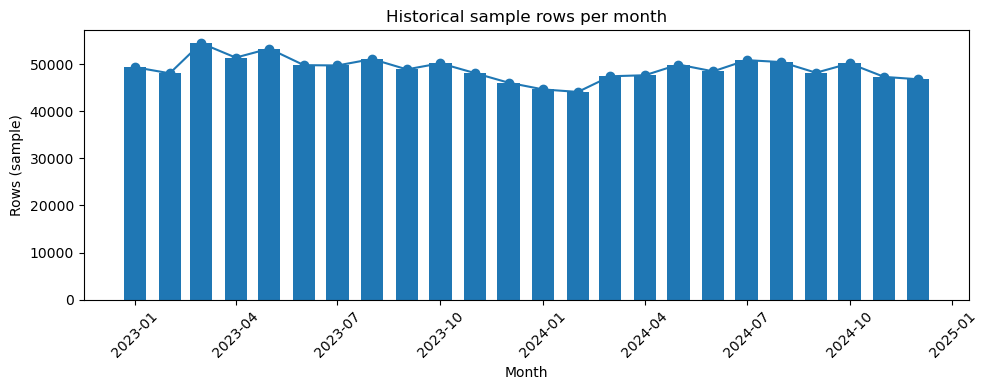


Top-20 columns by missing % (sample):
-----------------


CANCELLATION_CODE      97.633502
NAS_DELAY              80.236811
LATE_AIRCRAFT_DELAY    80.236811
CARRIER_DELAY          80.236811
WEATHER_DELAY          80.236811
SECURITY_DELAY         80.236811
ARR_DELAY_NEW           2.678114
ARR_DELAY_GROUP         2.678114
ARR_TIME                2.400933
DEP_DELAY_NEW           2.249759
DEP_DELAY_GROUP         2.249759
DEP_TIME                2.248143
FlightDate              0.000000
source_file             0.000000
sort_time               0.000000
ARR_TIME_BLK            0.000000
is_delayed_15           0.000000
DayOfWeek               0.000000
DIVERTED                0.000000
IsWeekend               0.000000
dtype: float64

In [44]:
if dataset_exists(HIST_PATH):
    print(f"Found historical dataset at: {HIST_PATH}")
    hist = open_dataset(HIST_PATH)
    print("\nSchema:\n-----------------")
    print_schema(hist)
    
    total_hist = count_rows(hist)
    print(f"\nTotal rows (historical): {total_hist:,}")
    
    print("\nHead (first 20 rows):\n-----------------")
    display(head_dataset(hist, 20))
    
    print("\nSampling for quick QC…")
    hist_sample = sample_dataset(hist, SAMPLE_N)
    print(f"Sample shape: {hist_sample.shape}")
    
    def show_monthly_counts(df: pd.DataFrame, title: str):
        if "FlightDate" not in df.columns:
            print("ERROR: 'FlightDate' column not found.")
            print("Columns:", list(df.columns))
            return
        
        # Robust parse
        s = df["FlightDate"]
        if not pd.api.types.is_datetime64_any_dtype(s):
            if pd.api.types.is_numeric_dtype(s):
                s = s.round().astype("Int64").astype(str)
                s = pd.to_datetime(s, format="%Y%m%d", errors="coerce")
            else:
                s = pd.to_datetime(s, errors="coerce")
        df = df.copy()
        df["FlightDate"] = s
        
        # Basic diagnostics
        n = len(df)
        n_nat = df["FlightDate"].isna().sum()
        print(f"Parsed FlightDate: {n - n_nat}/{n} non-null "
              f"({(1 - n_nat/max(n,1))*100:.1f}%).")
        if (n - n_nat) == 0:
            print("All FlightDate values are NaT. Check the source format.")
            return
        
        print("Date range (sample):", df["FlightDate"].min(), "->", df["FlightDate"].max())
        
        # Monthly counts
        df["__month__"] = df["FlightDate"].dt.to_period("M").dt.to_timestamp()
        counts = (
            df.groupby("__month__")
              .size()
              .rename("count")
              .sort_index()
              .reset_index()
        )
        print("\nMonthly counts (sample head):")
        print(counts.head(12).to_string(index=False))
        print(f"\nDistinct months in sample: {len(counts)}")
        
        if counts.empty:
            print("No rows with valid FlightDate in the sample; nothing to plot.")
            return
    
        # Plot: bars + markers (works well for few points)
        plt.figure(figsize=(10,4))
        plt.bar(counts["__month__"], counts["count"], width=20)  # ~bar per month
        plt.plot(counts["__month__"], counts["count"], marker="o")
        plt.title(title)
        plt.xlabel("Month")
        plt.ylabel("Rows (sample)")
        plt.xticks(rotation=45)
        # Nice y-lims even for single-point plots
        ymin, ymax = counts["count"].min(), counts["count"].max()
        if ymin == ymax:
            pad = max(1, int(0.05 * ymax))
            plt.ylim(ymin - pad, ymax + pad)
        plt.tight_layout()
        plt.show()
    
    # Use it:
    show_monthly_counts(hist_sample, "Historical sample rows per month")
        
    print("\nTop-20 columns by missing % (sample):\n-----------------")
    display(basic_null_report(hist_sample, 20))
else:
    print(f"Historical dataset NOT FOUND at: {HIST_PATH}")

## 2) Check Daily OOT Bronze Parquet (if present)

In [45]:
if dataset_exists(OOT_PATH):
    print(f"Found OOT dataset at: {OOT_PATH}")
    oot = open_dataset(OOT_PATH)
    print("\nSchema:\n-----------------")
    print_schema(oot)
    
    total_oot = count_rows(oot)
    print(f"\nTotal rows (OOT): {total_oot:,}")
    
    print("\nHead (first 20 rows):\n-----------------")
    display(head_dataset(oot, 20))
    
    print("\nSampling for quick QC…")
    oot_sample = sample_dataset(oot, SAMPLE_N)
    print(f"Sample shape: {oot_sample.shape}")
    
    date_col = try_find_date_col(oot_sample.columns)
    if date_col is not None:
        try:
            oot_sample[date_col] = pd.to_datetime(oot_sample[date_col])
            print(f"Detected date column: {date_col}")
            print("Date range (sample):", oot_sample[date_col].min(), "->", oot_sample[date_col].max())
        except Exception as e:
            print(f"Could not parse date column '{date_col}':", e)
    else:
        print("No obvious date column found.")
    
    print("\nTop-20 columns by missing % (sample):\n-----------------")
    display(basic_null_report(oot_sample, 20))
else:
    print(f"OOT dataset NOT FOUND at: {OOT_PATH}")

OOT dataset NOT FOUND at: ../../datamart/bronze/flight/bronze_flight_oot.parquet


## 3) Optional: Spark-based check (schema + counts)
Run this if your Jupyter kernel has PySpark available and you prefer Spark to read the dataset.

In [46]:
USE_SPARK = False  # flip to True if you want to test with Spark

if USE_SPARK:
    try:
        from pyspark.sql import SparkSession
        spark = SparkSession.builder.appName("BronzeQC").getOrCreate()
        spark.sparkContext.setLogLevel("ERROR")
        
        if dataset_exists(HIST_PATH):
            print("\n[SPARK] Historical parquet")
            dfh = spark.read.parquet(HIST_PATH)
            dfh.printSchema()
            print("Rows:", dfh.count())
            dfh.show(10, truncate=False)
        
        if dataset_exists(OOT_PATH):
            print("\n[SPARK] OOT parquet")
            dfo = spark.read.parquet(OOT_PATH)
            dfo.printSchema()
            print("Rows:", dfo.count())
            dfo.show(10, truncate=False)
        
    except Exception as e:
        print("Spark section failed:", e)

---
_Generated on 2025-10-25 13:14:20Z._